# CSCI/MATH 485 Assignment
## Customer Churn Prediction with XGBoost
## Starter Notebook

This notebook is compatible with **Jupyter Notebook** and **Google Colab**.

This starter code is only to get you started. You can change any of the existing code here to complete all the tasks.

Complete all `TODO` sections. Make sure your final submission includes:
- data analysis,
- a tuned XGBoost model,
- your chosen main evaluation metric and justification,
- interpretation of top important features,
- and a final comparison with the baseline model.


## 1. Setup


In [1]:
# If you are using Google Colab, uncomment the next line if xgboost is not installed.
# !pip install xgboost


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier


## 2. Load the Dataset

**Instructions for students**
- Load the IBM Telco Customer Churn dataset.
- Display the first few rows.
- Confirm the dataset shape.
- If the url doesn't work for you, download the csv file from the Canvas Assignment#4

In [3]:
url = "https://raw.githubusercontent.com/plotly/datasets/master/telco-customer-churn-by-IBM.csv"
df = pd.read_csv(url)

# Display the first 5 rows of the dataset (done below)
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# TODO:
# Display the shape of the dataset
print("Shape of the dataset:", df.shape)

Shape of the dataset: (7043, 21)


## 3. Data Exploration

Complete the following:
- Print all column names
- Show data types
- Count missing values in each column
- Show the distribution of the target variable
- Write a short note: Is this a classification or regression problem? Why is this useful in business?


Columns:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: ob

<Axes: xlabel='Churn'>

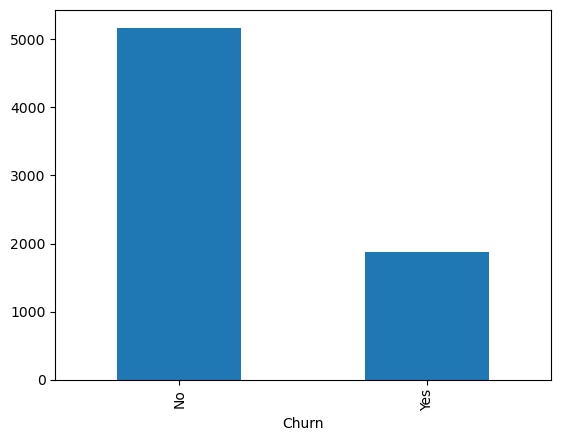

In [5]:
# TODO:
# Print column names
# Print data types
# Print missing values for each column
# Print value counts for the target column

print("Columns:")
# your code here
print(df.columns)
print("\nData types:")
# your code here
print(df.dtypes)
print("\nMissing values:")
# your code here
print(df.isnull().sum())
print("\nTarget distribution:")
# your code here
df['Churn'].value_counts().plot(kind="bar")

<Axes: xlabel='gender,Churn'>

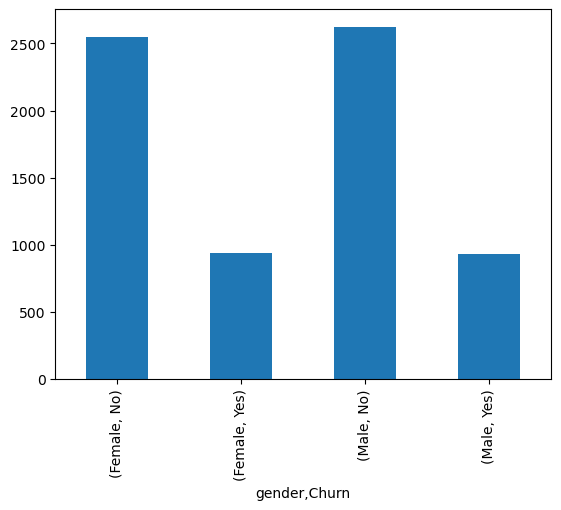

In [6]:
# Extra: display other information of the dataset that you think can be useful
df["Churn"].groupby(df["gender"]).value_counts().plot(kind="bar")


**TODO (write your answer below):**

1. What kind of machine learning problem is this?
-  This is classification problem because the target variable "Churn" is a binary variable (0 or 1) 
2. Why is churn prediction important in a business setting?
-  Customer acquisition typically costs more than retaining an existing customer. By predicting which customers are likely to leave, a company can target them with retention offers (e.g., discounts, upgraded plans) before they cancel. 

## 4. Basic Cleaning

Complet the following:
- Identify whether there is an ID column that should be removed
- Convert the target column into binary form if needed
- Convert any numeric-looking columns stored as text into numeric values


In [7]:
# Make a copy so the original data remains unchanged
df_clean = df.copy()

# TODO:
# 1. Drop any unnecessary identifier column(s)
# 2. Convert the target column to 0/1
# 3. Convert any columns that should be numeric into numeric type
# 4. Handle invalid parsing if needed

# Example structure only:
# df_clean = df_clean.drop(columns=[...])
# df_clean["Churn"] = df_clean["Churn"].map({"Yes": 1, "No": 0})
# df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

df_clean = df_clean.drop(columns=["customerID"])
df_clean["Churn"] = df_clean["Churn"].map({"Yes": 1, "No": 0})
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")
df_clean.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 5. Define Features and Target

Complet the following:
- Define `X` and `y`
- Set the correct target column


In [8]:
# TODO:
# Replace with the correct target column name
target_col = "Churn"

X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)


Feature matrix shape: (7043, 19)
Target shape: (7043,)


## 6. Identify Numeric and Categorical Features

Complet the following:
- Create a list of numeric columns
- Create a list of categorical columns


In [9]:
# TODO:
# Identify numeric and categorical feature columns

numeric_features = [col for col in X.columns if X[col].dtype != "object"]
categorical_features = [col for col in X.columns if X[col].dtype == "object"]

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


Numeric features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 7. Train/Test Split

Complet the following:
- Split the dataset into training and testing sets
- Use stratification if appropriate


In [10]:
# TODO:
# Create train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (5634, 19)
X_test shape: (1409, 19)


## 8. Preprocessing Pipelines

Build preprocessing for:
- numeric features
- categorical features

Then combine them into a `ColumnTransformer`.


In [11]:
# TODO:
# Build numeric preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# TODO:
# Build categorical preprocessing pipeline
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# TODO:
# Combine both preprocessing pipelines
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])

## 9. Baseline Model: Logistic Regression

Complet the following:
- Train a Logistic Regression model as the baseline
- Generate predictions
- Evaluate using multiple metrics
- You may need to adjust `max_iter` if the model is not converging.


In [12]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# TODO:
# Fit the baseline model
# Generate predicted labels
# Generate predicted probabilities

# your code here
baseline_model.fit(X_train, y_train)
baseline_preds = baseline_model.predict(X_test)
baseline_probs = baseline_model.predict_proba(X_test)[:, 1]

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
# TODO:
# Compute and print:
# - Accuracy
# - Precision
# - Recall
# - F1-score
# - ROC-AUC

# Suggested variable names:
# baseline_preds
# baseline_probs

# your code here
print("Accuracy:", accuracy_score(y_test,baseline_preds))
print("Precision:", precision_score(y_test, baseline_preds))
print("Recall:", recall_score(y_test, baseline_preds))
print("F1-score:", f1_score(y_test, baseline_preds))
print("ROC-AUC:", roc_auc_score(y_test, baseline_probs))

Accuracy: 0.8041163946061036
Precision: 0.6540880503144654
Recall: 0.5561497326203209
F1-score: 0.6011560693641619
ROC-AUC: 0.8425921620295022


In [14]:
# Optional but helpful
# TODO:
# Print classification report and confusion matrix

# your code here
print(confusion_matrix(y_test, baseline_preds))
print(classification_report(y_test, baseline_preds))

[[925 110]
 [166 208]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409



## 10. Choose Your Main Evaluation Metric

Choose **one main metric** for this churn problem.

You must explain:
- which metric you chose,
- why it is appropriate,
- and why it is more informative than accuracy alone for this problem.


**TODO (write your answer below):**

Main Evaluation Metric: ROC-AUC

The dataset is imbalanced — roughly 70% of customers did not churn and only 30% churned. In such settings, accuracy is misleading: a model that always predicts \"No Churn\" achieves ~70% accuracy while being completely useless for identifying churners. ROC-AUC measures the model's ability to rank churners above non-churners across all possible classification thresholds, making it threshold-agnostic. It ranges from 0.5 (random) to 1.0 (perfect), and is not affected by class imbalance in the way accuracy is.
  

## 11. XGBoost Model

Complet the following:
- Build an XGBoost pipeline
- Tune at least 3 hyperparameters
- Use either `GridSearchCV` or your own tuning approach


In [15]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ))
])

# TODO:
# Define a hyperparameter grid with at least 3 hyperparameters
param_grid = {
    # Example format:
    "classifier__n_estimators": range(50,500,50),
    "classifier__max_depth": range(3,10),
    "classifier__learning_rate": [0.05, 0.1]
}

param_grid


{'classifier__n_estimators': range(50, 500, 50),
 'classifier__max_depth': range(3, 10),
 'classifier__learning_rate': [0.05, 0.1]}

In [16]:
# TODO:
# Run GridSearchCV (or perform manual tuning)
# Choose a scoring metric that matches your selected main evaluation metric

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring="roc_auc",   # TODO: replace with your chosen scoring metric
    cv=3,
    n_jobs=-1,
    verbose=1
)

# TODO:
# Fit grid search on training data

# your code here
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 126 candidates, totalling 378 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median'))]),
                                                                         ['SeniorCitizen',
                                                                          'tenure',
                                                                          'MonthlyCharges',
                                                                          'TotalCharges']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         [...
                                                      max_delta_step=None,
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'classifier__learning_rate': [0.05, 0.1],
                         'classifier__max_depth': range(3, 10),
                         'classifier__n_estimators': range(50, 500, 50)},
             scoring='roc_auc', verbose=1)

In [17]:
# TODO:
# Print the best hyperparameters
# Save the best model

# your code here
grid_search.best_params_
best_model = grid_search.best_estimator_

## 12. Evaluate the Tuned XGBoost Model

Evaluate XGBoost using the same metrics as the baseline.


In [18]:
# TODO:
# Generate predictions and probabilities using the best XGBoost model

# Suggested variable names:
# xgb_preds
# xgb_probs

# your code here
xgb_preds = best_model.predict(X_test)
xgb_probs = best_model.predict_proba(X_test)[:, 1]

In [19]:
# TODO:
# Compute and print:
# - Accuracy
# - Precision
# - Recall
# - F1-score
# - ROC-AUC

# your code here
print("Accuracy:", accuracy_score(y_test, xgb_preds))
print("Precision:", precision_score(y_test, xgb_preds))
print("Recall:", recall_score(y_test, xgb_preds))
print("F1-score:", f1_score(y_test, xgb_preds))
print("ROC-AUC:", roc_auc_score(y_test, xgb_probs))

Accuracy: 0.8062455642299503
Precision: 0.6759581881533101
Recall: 0.5187165775401069
F1-score: 0.5869894099848714
ROC-AUC: 0.8455643390425999


In [20]:
# Optional but helpful
# TODO:
# Print classification report and confusion matrix

# your code here
print(confusion_matrix(y_test, xgb_preds))
print(classification_report(y_test, xgb_preds))

[[942  93]
 [180 194]]
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.68      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



## 13. Feature Importance

Use the trained XGBoost model to:
- extract feature importances,
- recover transformed feature names,
- display the top 5 to 10 most important features.


In [21]:
# TODO:
# Access the fitted preprocessor and fitted XGBoost classifier from the pipeline

# your code here
fitted_preprocessor = best_model.named_steps["preprocessor"]
fitted_xgb = best_model.named_steps["classifier"]

In [22]:
# TODO:
# Get transformed feature names
# Get feature importances
# Create a DataFrame sorted by importance


# your code here
feature_names = fitted_preprocessor.get_feature_names_out()
importances = fitted_xgb.feature_importances_

In [23]:
# TODO:
# Display the top 10 most important features

# your code here
importances_df = pd.DataFrame(importances, index=feature_names, columns=["importance"])
importances_df.sort_values(by="importance", ascending=False).head(10)

,importance
cat__Contract_Month-to-month,0.505277
cat__InternetService_Fiber optic,0.102020
cat__TechSupport_No,0.075147
cat__OnlineSecurity_No,0.050286
cat__PaymentMethod_Electronic check,0.031312
cat__MultipleLines_Yes,0.029215
num__tenure,0.024129
cat__StreamingMovies_Yes,0.019662
cat__Contract_Two year,0.017462
cat__Contract_One year,0.016604


## 14. Interpret the Top Features

Write a short interpretation of the most important features.

Your explanation should:
- use plain language,
- connect features to churn behavior,
- and explain what the company might learn from them.


**TODO (write your answer below):**

Monthly plan customers leave the most → get them to choose longer plans

Customers without support or security leave more → offer these services

New customers leave easily → give better support at the start


## 15. Final Comparison: Logistic Regression vs XGBoost

Compare the two models using your results.

Your discussion should answer:
- Which model performed better?
- On which metric(s)?
- Why might XGBoost perform better on this dataset?
- What is one limitation of XGBoost?


In [24]:
# TODO:
# Print a side-by-side comparison of the main metrics
# for Logistic Regression and XGBoost

# your code here
result = pd.DataFrame({
    "LogisticRegression": {
        "Accuracy": accuracy_score(y_test, baseline_preds),
        "Precision": precision_score(y_test, baseline_preds),
        "Recall": recall_score(y_test, baseline_preds),
        "F1-score": f1_score(y_test, baseline_preds),
        "ROC-AUC": roc_auc_score(y_test, baseline_probs)
    },
    "XGBoost": {
        "Accuracy": accuracy_score(y_test, xgb_preds),
        "Precision": precision_score(y_test, xgb_preds),
        "Recall": recall_score(y_test, xgb_preds),
        "F1-score": f1_score(y_test, xgb_preds),
        "ROC-AUC": roc_auc_score(y_test, xgb_probs)
    }
})
result

,LogisticRegression,XGBoost
Accuracy,0.804116,0.806246
Precision,0.654088,0.675958
Recall,0.556150,0.518717
F1-score,0.601156,0.586989
ROC-AUC,0.842592,0.845564


**TODO (write your answer below):**

Overall, both models perform similarly, with only small differences.

XGBoost performs slightly better in:
- Accuracy (0.806 vs 0.804)
- Precision (0.676 vs 0.654)
- ROC-AUC (0.846 vs 0.843)

Logistic Regression performs better in:
- Recall (0.556 vs 0.519)
- F1-score (0.601 vs 0.587)

So, there is no clear winner, but XGBoost is slightly better overall.

XGBoost limitation:

XGBoost is harder to interpret compared to Logistic Regression, which makes it more difficult to explain results.


## 16. Suggested Submission Checklist

Before submitting, make sure your notebook includes:
- completed code cells,
- outputs for each section,
- your selected main evaluation metric and justification,
- tuned XGBoost hyperparameters,
- feature importance results,
- interpretation of important features,
- and a final comparison of the two models.
